<a href="https://colab.research.google.com/github/febinemmanuel/assessment/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [63]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

#Read Data

In [44]:
filepath = '/content/drive/MyDrive/AI ML/IRP/datasets/heart_disease.csv'
df_heart_disease = pd.read_csv(filepath)
df_heart_disease.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#EDA

In [45]:
df_heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [46]:
df_heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [47]:
df_heart_disease.shape

(1025, 14)

In [48]:
df_heart_disease.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [49]:
df_heart_disease.duplicated().sum()

np.int64(723)

In [50]:
num_cols = []
cat_cols = []

In [51]:
num_cols = df_heart_disease.select_dtypes(include = ['int','float']).columns
num_cols

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [52]:
cat_cols = df_heart_disease.select_dtypes(['object']).columns
cat_cols

Index([], dtype='object')

##Visualization

###Histogram

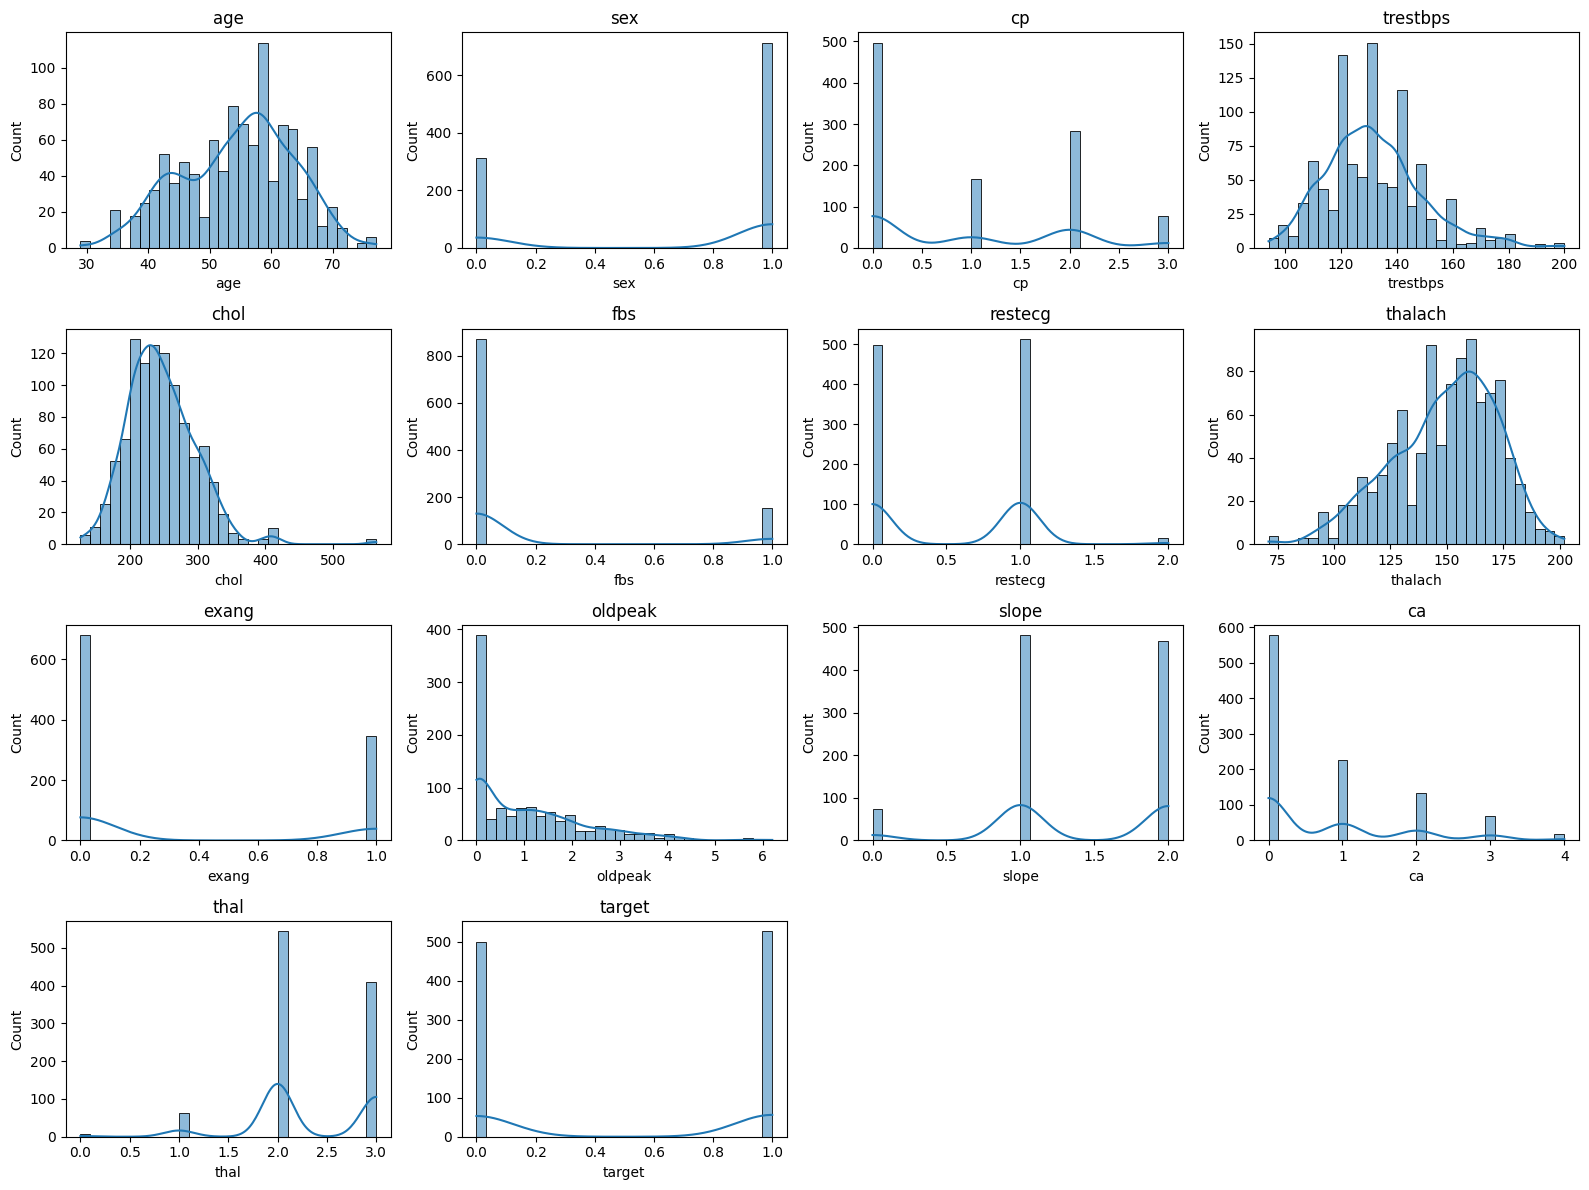

In [53]:
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.histplot(df_heart_disease[num_cols[i]], kde=True, bins=30)
  plt.title(num_cols[i])
plt.tight_layout()
plt.show()

##Outlier

###Boxplot

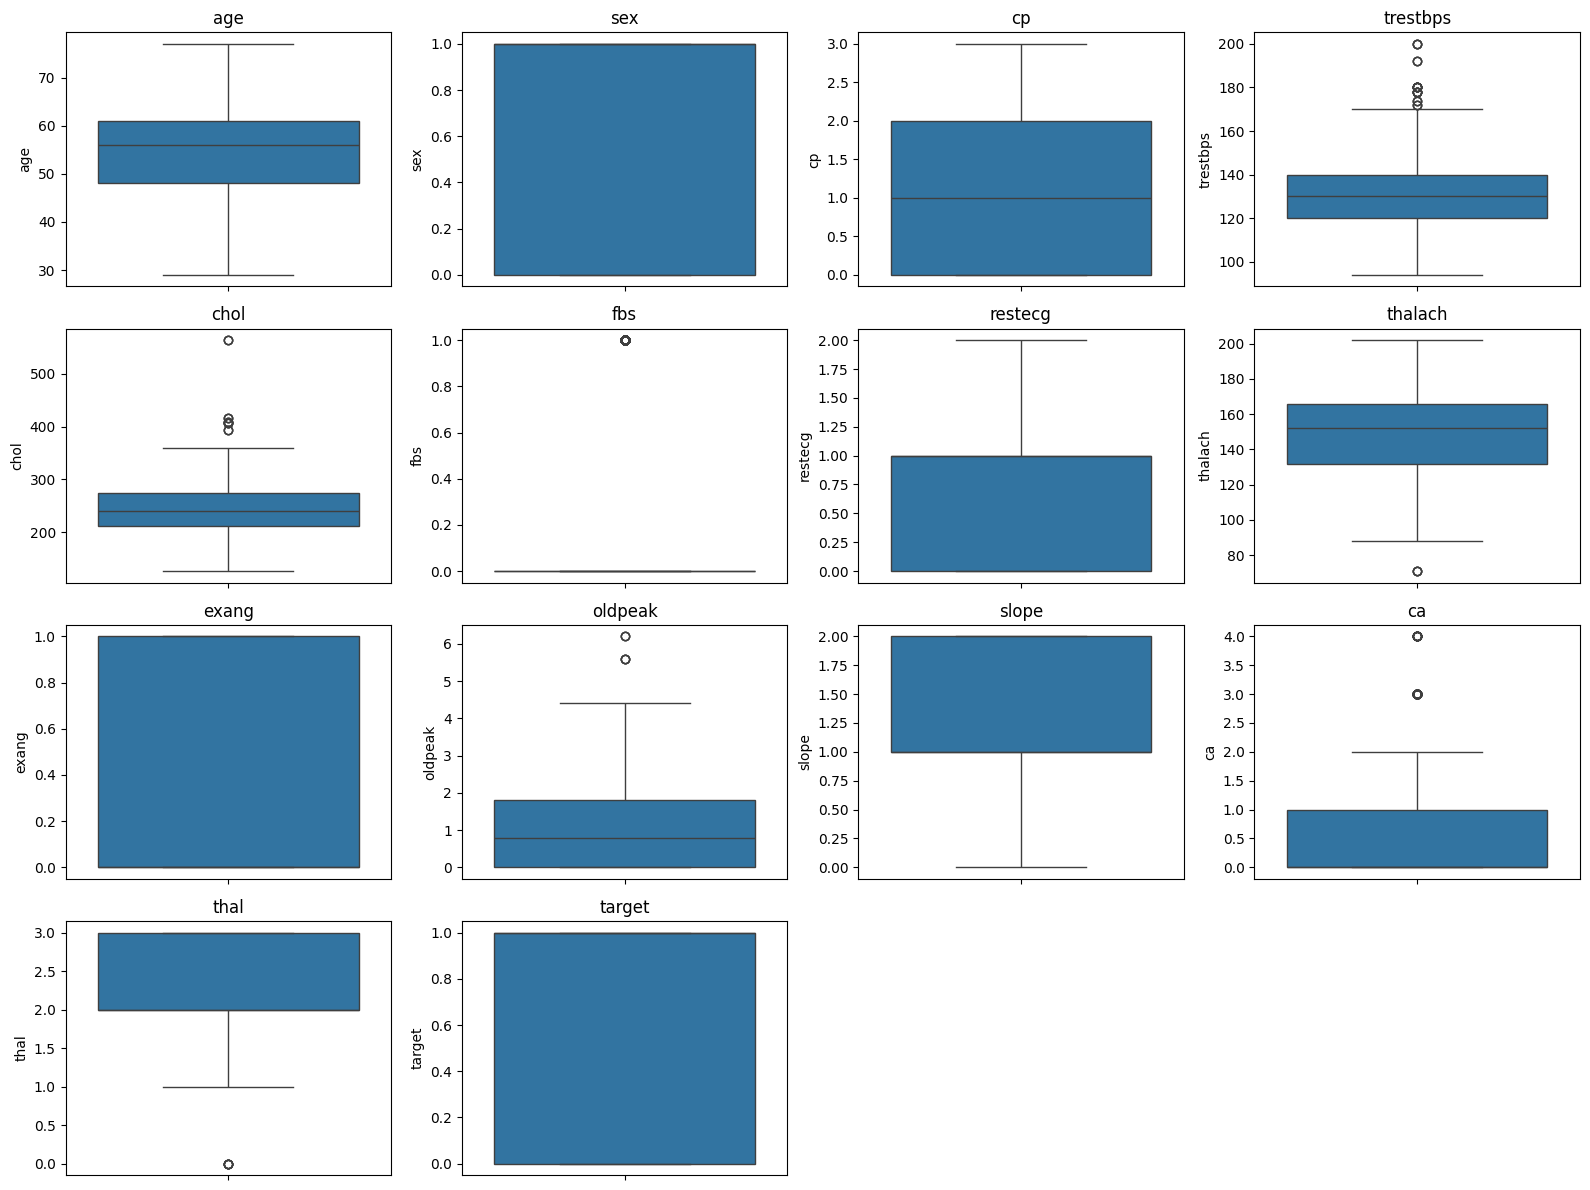

In [54]:
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.boxplot(df_heart_disease[num_cols[i]])
  plt.title(num_cols[i])
plt.tight_layout()
plt.show()

#Preprocessing

##Outlier Handling

In [55]:
outlier_cols = ['trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca', 'thal']

for i in outlier_cols:
  Q1 = df_heart_disease[i].quantile(0.25)
  Q3 = df_heart_disease[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")
  print(f"Lower Bound: {lower_bound}")
  print(f"Upper Bound: {upper_bound}")

Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower Bound: 90.0
Upper Bound: 170.0
Q1: 211.0
Q3: 275.0
IQR: 64.0
Lower Bound: 115.0
Upper Bound: 371.0
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 132.0
Q3: 166.0
IQR: 34.0
Lower Bound: 81.0
Upper Bound: 217.0
Q1: 0.0
Q3: 1.8
IQR: 1.8
Lower Bound: -2.7
Upper Bound: 4.5
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Q1: 2.0
Q3: 3.0
IQR: 1.0
Lower Bound: 0.5
Upper Bound: 4.5


In [56]:
# clipping

for i in outlier_cols:
  Q1 = df_heart_disease[i].quantile(0.25)
  Q3 = df_heart_disease[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_heart_disease[i] = df_heart_disease[i].clip(lower_bound, upper_bound)
  outliers = ((df_heart_disease[i] < lower_bound) | (df_heart_disease[i] > upper_bound))
  print(f'outliers: {outliers.sum()}')

outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0


##Encoding

In [57]:
df_heart_disease = pd.get_dummies(
    df_heart_disease,
    columns=['cp','restecg','thal'],
    drop_first=True
)

In [58]:
df_heart_disease.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1.0,thal_2.0,thal_3.0
0,52,1,125,212,0,168,0,1.0,2,2.0,0,False,False,False,True,False,False,False,True
1,53,1,140,203,0,155,1,3.1,0,0.0,0,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0.0,0,False,False,False,True,False,False,False,True
3,61,1,148,203,0,161,0,0.0,2,1.0,0,False,False,False,True,False,False,False,True
4,62,0,138,294,0,106,0,1.9,1,2.5,0,False,False,False,True,False,False,True,False


##Scaling

In [60]:
scale_cols = ['trestbps', 'thalach', 'oldpeak']

scaler = StandardScaler()
df_heart_disease[scale_cols] = scaler.fit_transform(df_heart_disease[scale_cols])

df_heart_disease.head(5)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1.0,thal_2.0,thal_3.0
0,52,1,-0.378869,212,0,0.824084,0,-0.054537,2,2.0,0,False,False,False,True,False,False,False,True
1,53,1,0.528894,203,0,0.255654,1,1.785457,0,0.0,0,False,False,False,False,False,False,False,True
2,70,1,0.831481,174,0,-1.056105,1,1.347363,0,0.0,0,False,False,False,True,False,False,False,True
3,61,1,1.013034,203,0,0.518006,0,-0.930725,2,1.0,0,False,False,False,True,False,False,False,True
4,62,0,0.407859,294,0,-1.886886,0,0.734031,1,2.5,0,False,False,False,True,False,False,True,False


#Train Test split

In [61]:
# for regression
X = df_heart_disease.drop('chol', axis=1)
y = df_heart_disease['chol']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Building / Regression

##Linear Regression

In [68]:
# create model object
lin_reg = LinearRegression()
# train the model
lin_reg.fit(X_train, y_train)
# make prediction using model
y_pred = lin_reg.predict(X_test)
# evaluvate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Mean absolute error : ", mae)
print("Mean squared error : ", mse)
print("Root mean squared error : ", rmse)

Mean absolute error :  37.89069257025846
Mean squared error :  2288.076558257764
Root mean squared error :  47.83384323110327


## SVM

In [69]:
# create model object
svm = SVR()
# train the model
svm.fit(X_train, y_train)
# make prediction using model
y_pred = svm.predict(X_test)
# evaluvate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Mean absolute error : ", mae)
print("Mean squared error : ", mse)
print("Root mean squared error : ", rmse)


Mean absolute error :  39.34062644037559
Mean squared error :  2441.684330513739
Root mean squared error :  49.41340233695448


##Random Forest

In [74]:
# create model object
rf = RandomForestRegressor(random_state=42)
# train the model
rf.fit(X_train, y_train)
# make prediction using model
y_pred = rf.predict(X_test)
# evaluvate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Mean absolute error : ", mae)
print("Mean squared error : ", mse)
print("Root mean squared error : ", rmse)


Mean absolute error :  8.170926829268293
Mean squared error :  166.16436585365858
Root mean squared error :  12.890475780732787


#/Classification

## Logistic regreesion

##KNN

##Random Forest